# Rentabilidade comercial

**Público:** gestores comerciais.  \n**Objetivo:** entender a evolução da rentabilidade e priorizar frentes de ação comercial.

## Os dados foram lidos corretamente?

A base anonimizada é carregada em blocos para preservar memória. A leitura usa `;` como separador e vírgula decimal.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:,.0f}'.format

In [2]:
COR_PRIMARIA, COR_DESTAQUE = '#0072B2', '#E69F00'
COR_EIXO, COR_TEXTO = '#B0B7C3', '#334155'
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11, 'text.color': COR_TEXTO, 'axes.titlesize': 15, 'axes.titleweight': 'bold', 'axes.titlecolor': COR_TEXTO, 'axes.labelcolor': COR_EIXO, 'axes.edgecolor': COR_EIXO, 'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': False, 'xtick.color': COR_EIXO, 'ytick.color': COR_EIXO})

## Como evoluíram faturamento e margem?

A pergunta orienta a comparação entre anos completos. O ano de 2026 será tratado como parcial.

In [3]:
ARQUIVO = Path('.data/base.gz')
if not ARQUIVO.exists():
    ARQUIVO = Path('../../.data/base.gz')

COLUNAS = ['DATA', 'NOME CLIENTE', 'NOME PRODUTO', 'NOME REVENDA', 'FAMILIA PRODUTO', 'VLR_LIQUIDO', 'VLR_CPV', 'VLR_MARGEM_CONTRIBUICAO', 'TONELAGEM']
METRICAS = ['VLR_LIQUIDO', 'VLR_CPV', 'VLR_MARGEM_CONTRIBUICAO', 'TONELAGEM']
GRUPOS = ['ANO', 'PERIODO', 'NOME CLIENTE', 'NOME PRODUTO', 'NOME REVENDA', 'FAMILIA PRODUTO']
resumos = {grupo: None for grupo in GRUPOS}

In [4]:
linhas = linhas_negativas = 0
margem_negativa = 0.0

for bloco in pd.read_csv(ARQUIVO, sep=';', decimal=',', usecols=COLUNAS, chunksize=100_000, low_memory=False):
    for metrica in METRICAS:
        bloco[metrica] = pd.to_numeric(bloco[metrica], errors='coerce')
    bloco['ANO'] = bloco['DATA'].astype(str).str.slice(0, 4)
    bloco['PERIODO'] = bloco['DATA'].astype(str).str.slice(0, 7)
    linhas += len(bloco)
    negativas = bloco['VLR_MARGEM_CONTRIBUICAO'] < 0
    linhas_negativas += negativas.sum()
    margem_negativa += bloco.loc[negativas, 'VLR_MARGEM_CONTRIBUICAO'].sum()
    for grupo in GRUPOS:
        agregado = bloco.groupby(grupo).agg(faturamento=('VLR_LIQUIDO', 'sum'), margem=('VLR_MARGEM_CONTRIBUICAO', 'sum'), linhas=('VLR_LIQUIDO', 'size'))
        resumos[grupo] = agregado if resumos[grupo] is None else resumos[grupo].add(agregado, fill_value=0)

In [5]:
for resumo in resumos.values():
    resumo['margem_pct'] = resumo['margem'] / resumo['faturamento']

anual = resumos['ANO'].sort_index()
validacao = pd.DataFrame({'linhas': [linhas], 'periodo_inicial': [resumos['PERIODO'].index.min()], 'periodo_final': [resumos['PERIODO'].index.max()], 'linhas_com_margem_negativa': [linhas_negativas]})
display(validacao)
display(anual[['faturamento', 'margem', 'margem_pct']].round(4))

,linhas,periodo_inicial,periodo_final,linhas_com_margem_negativa
0,2796421,2022-01,2026-03,1716884


,faturamento,margem,margem_pct
ANO,,,
2022,"2,511,592,953","272,883,820",0
2023,"2,045,759,700","245,124,751",0
2024,"1,996,826,362","300,526,981",0
2025,"1,817,904,874","324,255,952",0
2026,"249,520,913","67,327,321",0


**Leitura gerencial:** anos completos são 2022 a 2025. O recorte de 2026 contém janeiro a março e não deve ser comparado como ano fechado.

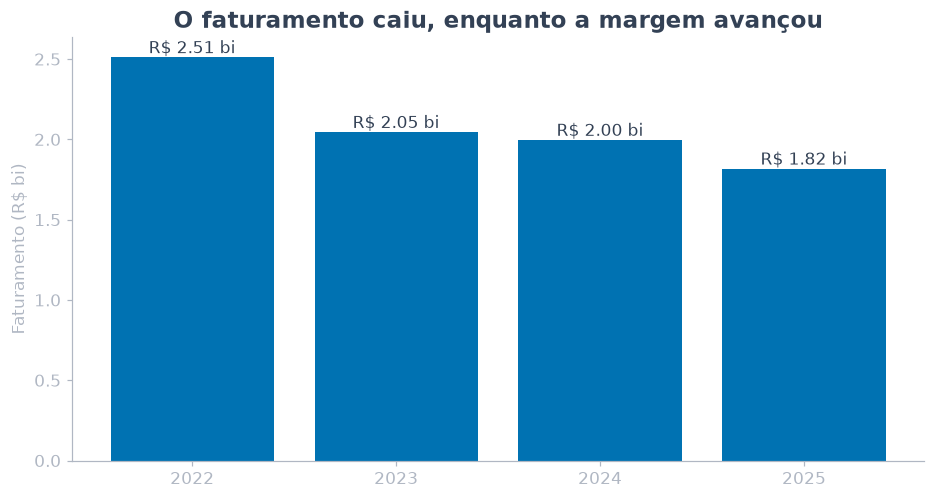

In [6]:
anos_fechados = anual.loc[anual.index <= '2025']
fig, ax = plt.subplots(figsize=(10, 5))
barras = ax.bar(anos_fechados.index, anos_fechados['faturamento'] / 1e9, color=COR_PRIMARIA)
ax.set_title('O faturamento caiu, enquanto a margem avançou')
ax.set_ylabel('Faturamento (R$ bi)')
for barra, valor in zip(barras, anos_fechados['faturamento'] / 1e9):
    ax.text(barra.get_x() + barra.get_width() / 2, valor, f'R$ {valor:.2f} bi', ha='center', va='bottom')
plt.show()

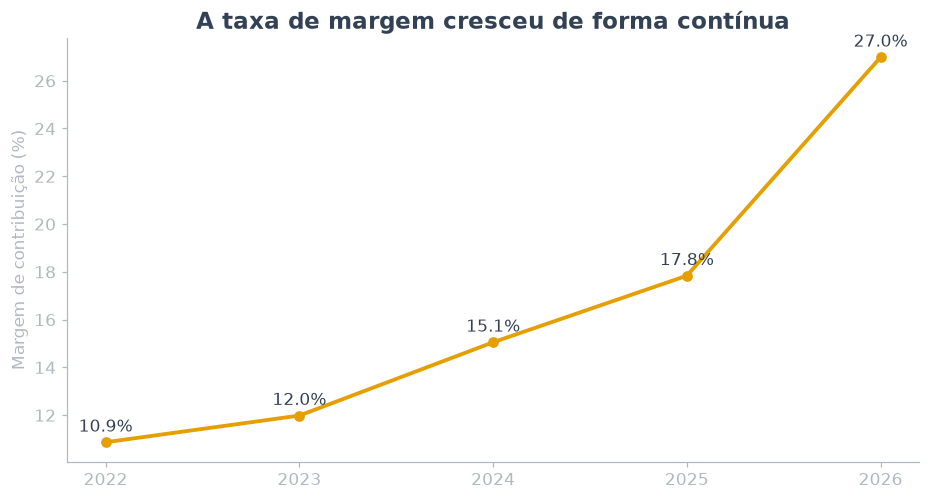

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
serie = anual['margem_pct'] * 100
ax.plot(serie.index, serie, marker='o', linewidth=2.5, color=COR_DESTAQUE)
ax.set_title('A taxa de margem cresceu de forma contínua')
ax.set_ylabel('Margem de contribuição (%)')
for periodo, valor in serie.items():
    ax.annotate(f'{valor:.1f}%', (periodo, valor), xytext=(0, 7), textcoords='offset points', ha='center')
plt.show()

## Onde estão as perdas que merecem prioridade?

Usamos perda absoluta de margem, pois combina impacto financeiro e capacidade de ação. Taxas isoladas podem distorcer grupos com faturamento baixo ou negativo.

In [8]:
familias_perdedoras = resumos['FAMILIA PRODUTO'].query('margem < 0').sort_values('margem').head(10)
produtos_perdedores = resumos['NOME PRODUTO'].query('margem < 0').sort_values('margem').head(10)
revendas_perdedoras = resumos['NOME REVENDA'].query('margem < 0').sort_values('margem').head(10)

display(familias_perdedoras[['faturamento', 'margem', 'margem_pct', 'linhas']].round(4))
display(produtos_perdedores[['faturamento', 'margem', 'margem_pct', 'linhas']].round(4))

,faturamento,margem,margem_pct,linhas
FAMILIA PRODUTO,,,,
Linha de Varejo 39,"500,169,187","-13,315,662",-0,"403,396"
Linha de Varejo 35,"178,758,128","-11,871,058",-0,"133,111"
Linha de Varejo 34,"148,129,330","-7,123,614",-0,"10,356"
Linha de Varejo 98,"69,944,499","-4,609,449",-0,"18,854"
Linha de Varejo 96,"76,344,578","-4,112,448",-0,"7,312"
Linha de Varejo 43,"63,151,096","-3,168,411",-0,"65,287"
Linha de Varejo 42,"252,824,811","-2,716,768",-0,"247,354"
Linha de Varejo 36,"105,025,719","-2,527,905",-0,"1,594"
Linha de Varejo 26,"29,695,858","-721,729",-0,"19,954"


,faturamento,margem,margem_pct,linhas
NOME PRODUTO,,,,
Produto de Varejo 3252 | PRD-3252,"74,790,912","-4,446,930",-0,"2,383"
Produto de Varejo 3253 | PRD-3253,"62,262,971","-3,786,914",-0,"1,810"
Produto de Varejo 3328 | PRD-3328,"72,296,065","-3,558,588",-0,"3,749"
Produto de Varejo 4692 | PRD-4692,"54,103,191","-3,308,430",-0,"5,067"
Produto de Varejo 3258 | PRD-3258,"66,036,509","-2,583,693",-0,661
Produto de Varejo 3061 | PRD-3061,"33,439,014","-2,372,581",-0,"21,020"
Produto de Varejo 2946 | PRD-2946,"34,994,399","-2,267,328",-0,"23,134"
Produto de Varejo 3306 | PRD-3306,"48,208,978","-2,157,432",-0,"4,290"
Produto de Varejo 4691 | PRD-4691,"29,156,063","-2,112,847",-0,"5,226"


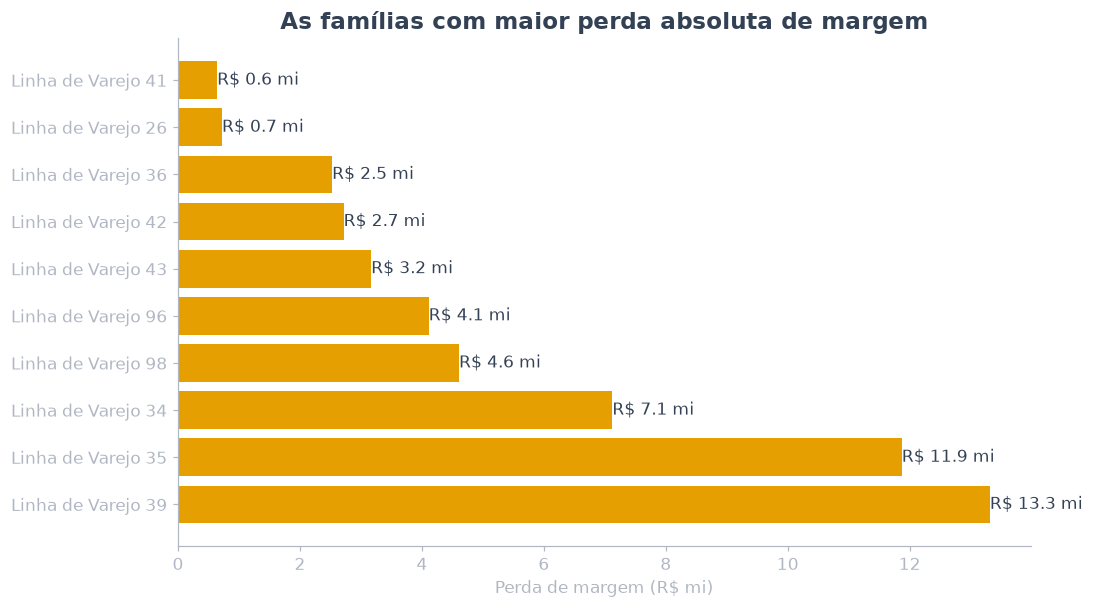

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
ranking = familias_perdedoras.sort_values('margem')
barras = ax.barh(ranking.index, -ranking['margem'] / 1e6, color=COR_DESTAQUE)
ax.set_title('As famílias com maior perda absoluta de margem')
ax.set_xlabel('Perda de margem (R$ mi)')
for barra, valor in zip(barras, -ranking['margem'] / 1e6):
    ax.text(valor, barra.get_y() + barra.get_height() / 2, f'R$ {valor:.1f} mi', va='center', ha='left')
plt.show()

In [10]:
perda_total = -resumos['FAMILIA PRODUTO'].query('margem < 0')['margem'].sum()
concentracao_top10 = -familias_perdedoras['margem'].sum() / perda_total
painel = pd.DataFrame({'indicador': ['Margem negativa acumulada', 'Participação de linhas com margem negativa', 'Concentração das 10 famílias críticas'], 'valor': [margem_negativa, linhas_negativas / linhas, concentracao_top10]})
display(painel)

,indicador,valor
0,Margem negativa acumulada,"-185,863,150"
1,Participação de linhas com margem negativa,1
2,Concentração das 10 famílias críticas,1


## Como se distribui o perfil transacional dos clientes?

Como a base não possui dados demográficos, o perfil é construído a partir de faturamento, margem, frequência, variedade de produtos e meses ativos. São padrões de compra observados, não características individuais.

In [11]:
COLUNAS_PERFIL = ['DATA', 'NOME CLIENTE', 'NOME PRODUTO', 'FAMILIA PRODUTO', 'VLR_LIQUIDO', 'VLR_MARGEM_CONTRIBUICAO']
clientes, carteira_anual = None, None
produtos_cliente, familias_cliente, periodos_cliente, ultima_compra = {}, {}, {}, {}

In [12]:
for bloco in pd.read_csv(ARQUIVO, sep=';', decimal=',', usecols=COLUNAS_PERFIL, chunksize=100_000, low_memory=False):
    for metrica in ['VLR_LIQUIDO', 'VLR_MARGEM_CONTRIBUICAO']:
        bloco[metrica] = pd.to_numeric(bloco[metrica], errors='coerce')
    bloco['ANO'] = bloco['DATA'].astype(str).str.slice(0, 4)
    bloco['PERIODO'] = bloco['DATA'].astype(str).str.slice(0, 7)
    agregado = bloco.groupby('NOME CLIENTE').agg(faturamento=('VLR_LIQUIDO', 'sum'), margem=('VLR_MARGEM_CONTRIBUICAO', 'sum'), linhas=('VLR_LIQUIDO', 'size'))
    clientes = agregado if clientes is None else clientes.add(agregado, fill_value=0)
    anual_cliente = bloco.groupby(['NOME CLIENTE', 'ANO']).agg(faturamento=('VLR_LIQUIDO', 'sum'))
    carteira_anual = anual_cliente if carteira_anual is None else carteira_anual.add(anual_cliente, fill_value=0)
    for cliente, grupo in bloco.groupby('NOME CLIENTE'):
        produtos_cliente.setdefault(cliente, set()).update(grupo['NOME PRODUTO'].dropna())
        familias_cliente.setdefault(cliente, set()).update(grupo['FAMILIA PRODUTO'].dropna())
        periodos_cliente.setdefault(cliente, set()).update(grupo['PERIODO'].dropna())
        ultima_compra[cliente] = max(ultima_compra.get(cliente, ''), grupo['DATA'].max())

In [13]:
perfil = clientes.loc[clientes['faturamento'] > 0].copy()
perfil['margem_pct'] = perfil['margem'] / perfil['faturamento']
perfil['produtos_distintos'] = pd.Series({cliente: len(itens) for cliente, itens in produtos_cliente.items()})
perfil['familias_distintas'] = pd.Series({cliente: len(itens) for cliente, itens in familias_cliente.items()})
perfil['meses_ativos'] = pd.Series({cliente: len(itens) for cliente, itens in periodos_cliente.items()})
perfil['ultima_compra'] = pd.to_datetime(pd.Series(ultima_compra), errors='coerce')
referencia = perfil['ultima_compra'].max()
perfil['meses_sem_compra'] = (referencia.year - perfil['ultima_compra'].dt.year) * 12 + referencia.month - perfil['ultima_compra'].dt.month
display(perfil[['faturamento', 'margem', 'margem_pct', 'produtos_distintos', 'meses_ativos', 'meses_sem_compra']].head(8).round(4))

/var/folders/x2/yjty72zn4916zsbt7mnqzxjc0000gn/T/ipykernel_4033/2091666844.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  perfil['ultima_compra'] = pd.to_datetime(pd.Series(ultima_compra), errors='coerce')


,faturamento,margem,margem_pct,produtos_distintos,meses_ativos,meses_sem_compra
NOME CLIENTE,,,,,,
Abreu,"20,781","-1,852",-0,8,20,17
Abreu - EI,"48,105","-1,156",-0,69,28,13
Abreu - ME,"21,181","-1,011",-0,4,13,15
Abreu Abreu - ME,"5,812","5,665",1,1,2,44
Abreu Abreu S.A.,681,-174,-0,4,3,39
Abreu Albuquerque Ltda.,"102,923","12,193",0,1,8,4
Abreu Albuquerque S.A.,"298,595","47,621",0,1,3,35
Abreu Albuquerque S/A,"3,125",-114,-0,3,2,29


## Quais clientes devem ser protegidos, recuperados, desenvolvidos ou racionalizados?

A matriz combina faturamento e taxa de margem em relação às medianas da carteira. Ela é uma priorização comercial, não uma avaliação causal de cada cliente.

In [14]:
corte_faturamento = perfil['faturamento'].median()
corte_margem = perfil['margem_pct'].median()
perfil['perfil_comercial'] = 'Racionalizar'
perfil.loc[(perfil['faturamento'] >= corte_faturamento) & (perfil['margem_pct'] >= corte_margem), 'perfil_comercial'] = 'Proteger'
perfil.loc[(perfil['faturamento'] >= corte_faturamento) & (perfil['margem_pct'] < corte_margem), 'perfil_comercial'] = 'Recuperar margem'
perfil.loc[(perfil['faturamento'] < corte_faturamento) & (perfil['margem_pct'] >= corte_margem), 'perfil_comercial'] = 'Desenvolver'
amostra_perfil = perfil[['perfil_comercial', 'faturamento', 'margem_pct']].head(8).copy()
amostra_perfil['margem_pct'] = amostra_perfil['margem_pct'].map('{:.1%}'.format)
display(amostra_perfil)

,perfil_comercial,faturamento,margem_pct
NOME CLIENTE,,,
Abreu,Recuperar margem,"20,781",-8.9%
Abreu - EI,Recuperar margem,"48,105",-2.4%
Abreu - ME,Recuperar margem,"21,181",-4.8%
Abreu Abreu - ME,Desenvolver,"5,812",97.5%
Abreu Abreu S.A.,Racionalizar,681,-25.5%
Abreu Albuquerque Ltda.,Proteger,"102,923",11.8%
Abreu Albuquerque S.A.,Proteger,"298,595",15.9%
Abreu Albuquerque S/A,Racionalizar,"3,125",-3.6%


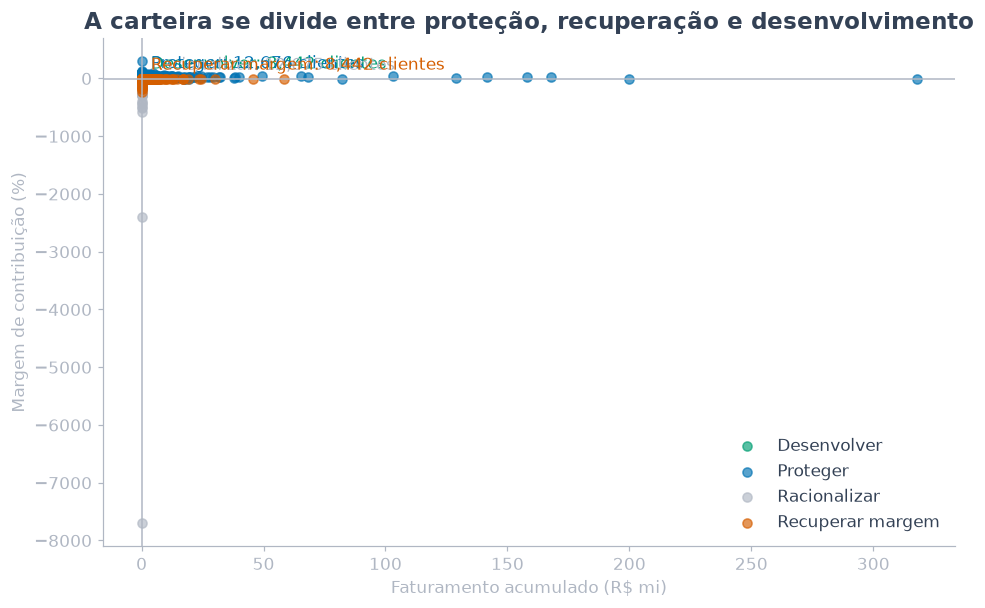

In [15]:
cores_perfil = {'Proteger': COR_PRIMARIA, 'Recuperar margem': '#D55E00', 'Desenvolver': '#009E73', 'Racionalizar': COR_EIXO}
fig, ax = plt.subplots(figsize=(10, 6))
for categoria, grupo in perfil.groupby('perfil_comercial'):
    ax.scatter(grupo['faturamento'] / 1e6, grupo['margem_pct'] * 100, label=categoria, color=cores_perfil[categoria], alpha=.65)
ax.axvline(corte_faturamento / 1e6, color=COR_EIXO, linewidth=1)
ax.axhline(corte_margem * 100, color=COR_EIXO, linewidth=1)
ax.set_title('A carteira se divide entre proteção, recuperação e desenvolvimento')
ax.set_xlabel('Faturamento acumulado (R$ mi)')
ax.set_ylabel('Margem de contribuição (%)')
centros = perfil.groupby('perfil_comercial').agg(faturamento=('faturamento', 'median'), margem_pct=('margem_pct', 'median'), clientes=('faturamento', 'size'))
for categoria, centro in centros.iterrows():
    ax.annotate(f"{categoria}: {centro['clientes']:,.0f} clientes", (centro['faturamento'] / 1e6, centro['margem_pct'] * 100), xytext=(6, 6), textcoords='offset points', color=cores_perfil[categoria])
ax.legend(frameon=False, loc='best')
plt.show()

## Quais padrões de recorrência e mix diferenciam os perfis?

Comparamos meses ativos, variedade de produtos e tempo desde a última compra observada. Esses indicadores ajudam a orientar cobertura comercial e expansão de mix.

In [16]:
padroes = perfil.groupby('perfil_comercial').agg(clientes=('faturamento', 'size'), meses_ativos_mediana=('meses_ativos', 'median'), produtos_mediana=('produtos_distintos', 'median'), familias_mediana=('familias_distintas', 'median'), meses_sem_compra_mediana=('meses_sem_compra', 'median')).sort_values('clientes', ascending=False)
display(padroes)

,clientes,meses_ativos_mediana,produtos_mediana,familias_mediana,meses_sem_compra_mediana
perfil_comercial,,,,,
Proteger,12676,7,7,4,14
Racionalizar,12675,3,7,3,31
Desenvolver,8442,2,3,2,33
Recuperar margem,8442,16,22,6,14


## Quais padrões de compra indicam oportunidade?

Comparamos 2025 contra 2024 entre clientes rentáveis. A queda sinaliza prioridade de investigação comercial; ela não prova, por si só, perda de cliente ou mudança de preferência.

In [17]:
faturamento_anual = carteira_anual['faturamento'].unstack(fill_value=0)
perfil['faturamento_2024'] = faturamento_anual.get('2024', pd.Series(0, index=perfil.index))
perfil['faturamento_2025'] = faturamento_anual.get('2025', pd.Series(0, index=perfil.index))
perfil['variacao_2025'] = perfil['faturamento_2025'] - perfil['faturamento_2024']
oportunidades = perfil[(perfil['margem'] > 0) & (perfil['faturamento_2024'] >= 1_000_000) & (perfil['variacao_2025'] < 0)].sort_values('variacao_2025').head(10)
visao_oportunidades = oportunidades[['faturamento_2024', 'faturamento_2025', 'variacao_2025', 'margem_pct', 'produtos_distintos', 'meses_sem_compra']].copy()
visao_oportunidades['margem_pct'] = visao_oportunidades['margem_pct'].map('{:.1%}'.format)
display(visao_oportunidades)

,faturamento_2024,faturamento_2025,variacao_2025,margem_pct,produtos_distintos,meses_sem_compra
NOME CLIENTE,,,,,,
da Rosa Cavalcanti - EI,"53,166,091","38,806,582","-14,359,509",19.1%,21,0
Lopes Azevedo S/A,"14,297,913",0,"-14,297,913",20.4%,16,0
Campos Carvalho Ltda.,"5,384,397",0,"-5,384,397",14.2%,1,15
Martins Monteiro S/A,"5,014,892",0,"-5,014,892",30.3%,1,22
Carvalho da Cruz Ltda.,"3,628,014","83,771","-3,544,242",23.9%,10,0
Rodrigues Cavalcanti Ltda.,"5,406,039","2,417,535","-2,988,505",18.9%,20,8
Sá Peixoto e Filhos,"2,996,443","53,911","-2,942,532",22.4%,25,14
Vargas Rios e Filhos,"10,675,390","8,026,812","-2,648,579",49.5%,23,0
Gomes Casa Grande S/A,"2,474,311","1,138","-2,473,174",18.6%,79,14


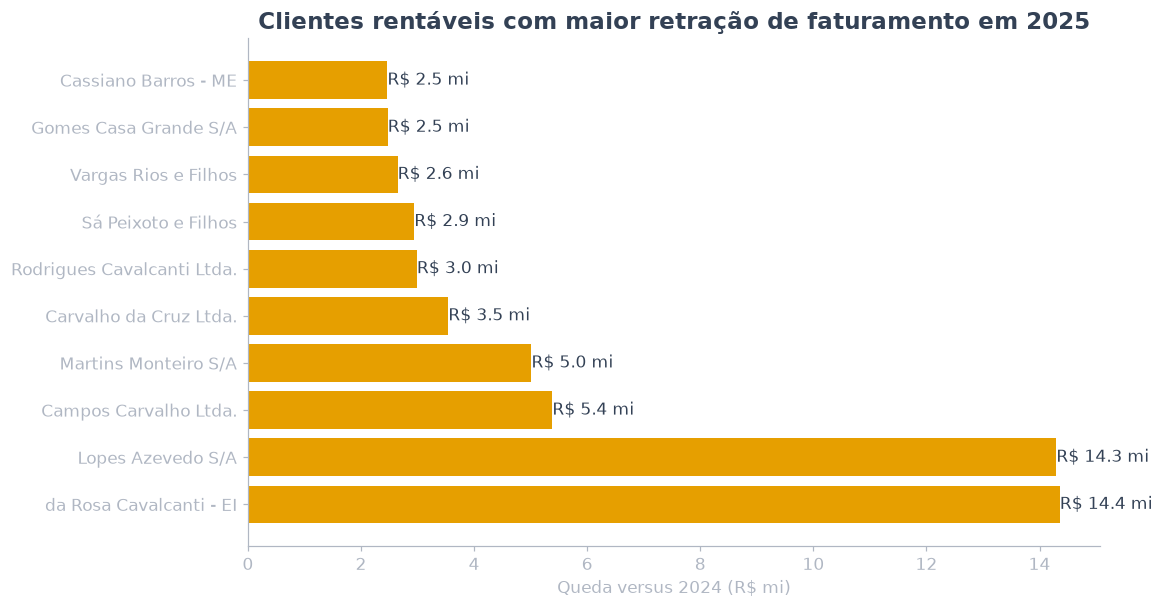

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
ranking = oportunidades.sort_values('variacao_2025')
barras = ax.barh(ranking.index, -ranking['variacao_2025'] / 1e6, color=COR_DESTAQUE)
ax.set_title('Clientes rentáveis com maior retração de faturamento em 2025')
ax.set_xlabel('Queda versus 2024 (R$ mi)')
for barra, valor in zip(barras, -ranking['variacao_2025'] / 1e6):
    ax.text(valor, barra.get_y() + barra.get_height() / 2, f'R$ {valor:.1f} mi', va='center', ha='left')
plt.show()

,clientes,faturamento,margem
perfil_comercial,,,
Proteger,12676,"6,678,771,325","1,325,066,063"
Recuperar margem,8442,"1,821,608,090","-115,202,892"
Racionalizar,12675,"70,312,969","-7,586,927"
Desenvolver,8442,"57,007,994","9,053,621"


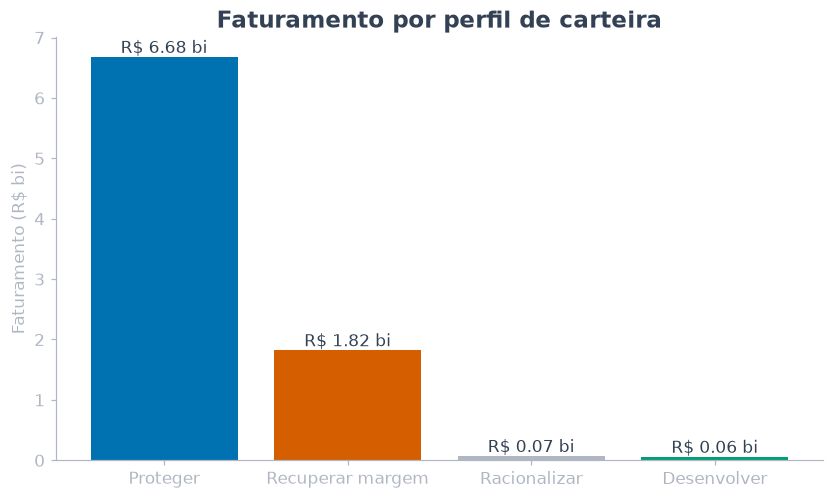

In [19]:
distribuicao = perfil.groupby('perfil_comercial').agg(clientes=('faturamento', 'size'), faturamento=('faturamento', 'sum'), margem=('margem', 'sum')).sort_values('faturamento', ascending=False)
display(distribuicao)

fig, ax = plt.subplots(figsize=(9, 5))
barras = ax.bar(distribuicao.index, distribuicao['faturamento'] / 1e9, color=[cores_perfil[x] for x in distribuicao.index])
ax.set_title('Faturamento por perfil de carteira')
ax.set_ylabel('Faturamento (R$ bi)')
for barra, valor in zip(barras, distribuicao['faturamento'] / 1e9):
    ax.text(barra.get_x() + barra.get_width() / 2, valor, f'R$ {valor:.2f} bi', ha='center', va='bottom')
plt.show()

**Implicações comerciais:** proteja os clientes que combinam escala e margem; negocie condições e mix dos clientes de alto valor com margem abaixo da mediana; desenvolva os clientes menores e rentáveis com expansão de mix; e investigue os rentáveis em retração antes de tratar o sinal como perda definitiva. A variação de cobertura da base ao longo do tempo limita conclusões causais sobre queda de compra.

## Qual é o risco de churn observado na carteira?

Churn observado significa ausência de compra por mais de 12 meses até a última data disponível na base. Não é confirmação de cancelamento: ele sinaliza uma prioridade de investigação comercial.

In [20]:
perfil['status_churn'] = 'Churn observado (> 12 meses)'
perfil.loc[perfil['meses_sem_compra'] <= 12, 'status_churn'] = 'Em risco (4 a 12 meses)'
perfil.loc[perfil['meses_sem_compra'] <= 3, 'status_churn'] = 'Ativo (até 3 meses)'

churn = perfil.groupby('status_churn').agg(clientes=('faturamento', 'size'), faturamento=('faturamento', 'sum'), margem=('margem', 'sum')).reindex(['Ativo (até 3 meses)', 'Em risco (4 a 12 meses)', 'Churn observado (> 12 meses)'])
display(churn)

,clientes,faturamento,margem
status_churn,,,
Ativo (até 3 meses),3701,"4,005,021,566","949,127,118"
Em risco (4 a 12 meses),8420,"2,738,905,266","87,910,052"
Churn observado (> 12 meses),30114,"1,883,773,546","174,292,695"


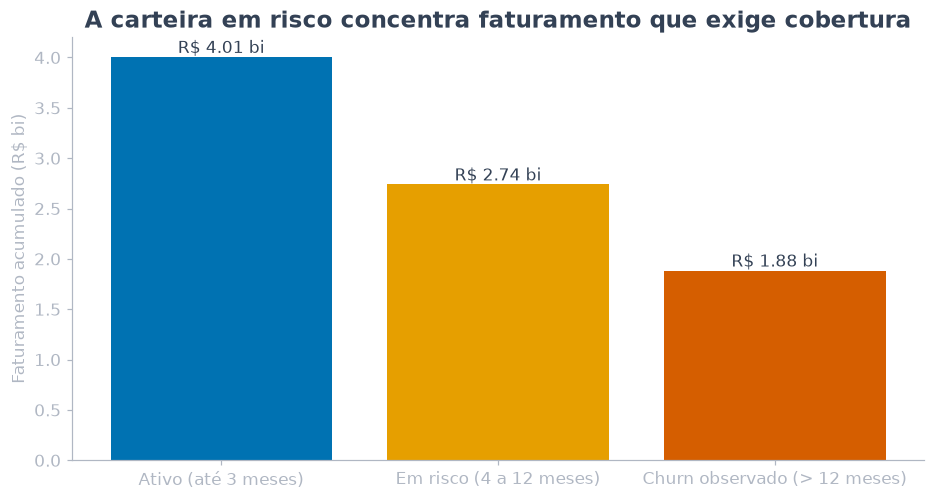

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
barras = ax.bar(churn.index, churn['faturamento'] / 1e9, color=[COR_PRIMARIA, COR_DESTAQUE, '#D55E00'])
ax.set_title('A carteira em risco concentra faturamento que exige cobertura')
ax.set_ylabel('Faturamento acumulado (R$ bi)')
for barra, valor in zip(barras, churn['faturamento'] / 1e9):
    ax.text(barra.get_x() + barra.get_width() / 2, valor, f'R$ {valor:.2f} bi', ha='center', va='bottom')
plt.xticks(rotation=0)
plt.show()

## Como a carteira se organiza pela análise RFV?

RFV combina **R**ecência (quanto menor o tempo sem compra, melhor), **F**requência (meses ativos) e **V**alor (faturamento). Os escores usam quintis da própria carteira; são prioridades relativas, não metas absolutas.

In [22]:
def escore_quintil(serie, maior_melhor=True):
    escala = pd.qcut(serie.rank(method='first'), 5, labels=False) + 1
    return escala if maior_melhor else 6 - escala

rfv = perfil.copy()
rfv['R'] = escore_quintil(rfv['meses_sem_compra'], maior_melhor=False)
rfv['F'] = escore_quintil(rfv['meses_ativos'])
rfv['V'] = escore_quintil(rfv['faturamento'])
rfv['RFV'] = rfv[['R', 'F', 'V']].sum(axis=1)

In [23]:
rfv['grupo_rfv'] = 'Ocasional'
rfv.loc[rfv['RFV'] >= 13, 'grupo_rfv'] = 'Campeões'
rfv.loc[(rfv['R'] >= 4) & (rfv['F'] >= 3) & (rfv['RFV'] < 13), 'grupo_rfv'] = 'Fiéis'
rfv.loc[(rfv['R'] <= 2) & (rfv['V'] >= 3), 'grupo_rfv'] = 'Em risco de perda'
rfv.loc[(rfv['V'] >= 4) & (rfv['F'] <= 2), 'grupo_rfv'] = 'Potencial a desenvolver'

resumo_rfv = rfv.groupby('grupo_rfv').agg(clientes=('faturamento', 'size'), faturamento=('faturamento', 'sum'), margem=('margem', 'sum')).sort_values('faturamento', ascending=False)
resumo_rfv['margem_pct_ponderada'] = resumo_rfv['margem'] / resumo_rfv['faturamento']
visao_rfv = resumo_rfv.copy()
visao_rfv['margem_pct_ponderada'] = visao_rfv['margem_pct_ponderada'].map('{:.1%}'.format)
display(visao_rfv)

,clientes,faturamento,margem,margem_pct_ponderada
grupo_rfv,,,,
Campeões,8866,"7,297,855,930","1,076,109,504",14.7%
Em risco de perda,5597,"571,013,564","55,309,167",9.7%
Ocasional,20124,"397,362,308","37,523,124",9.4%
Potencial a desenvolver,2265,"195,202,078","29,278,167",15.0%
Fiéis,5383,"166,266,498","13,109,903",7.9%


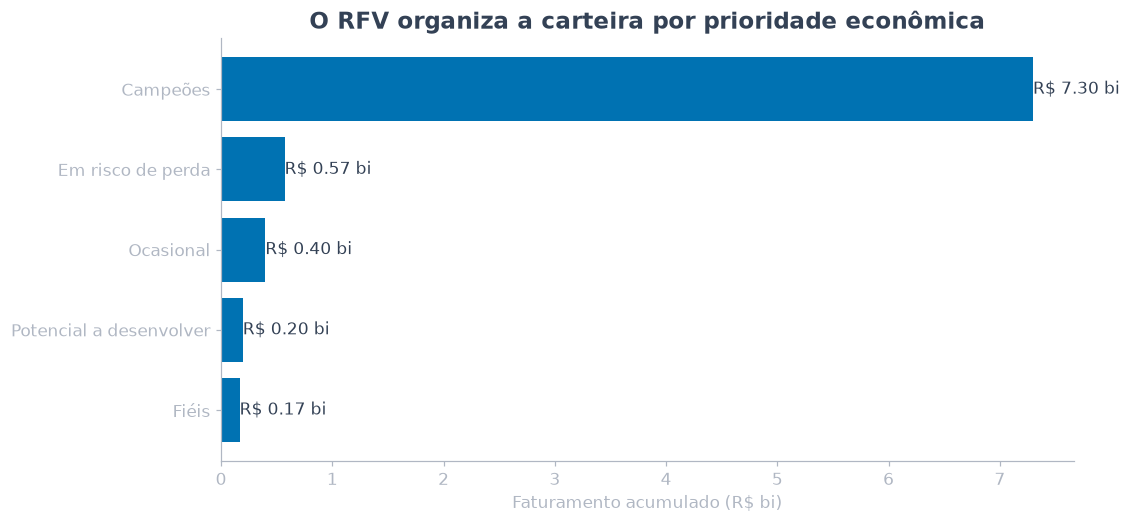

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
ranking = resumo_rfv.sort_values('faturamento')
barras = ax.barh(ranking.index, ranking['faturamento'] / 1e9, color=COR_PRIMARIA)
ax.set_title('O RFV organiza a carteira por prioridade econômica')
ax.set_xlabel('Faturamento acumulado (R$ bi)')
for barra, valor in zip(barras, ranking['faturamento'] / 1e9):
    ax.text(valor, barra.get_y() + barra.get_height() / 2, f'R$ {valor:.2f} bi', va='center', ha='left')
plt.show()

## Quais clientes têm perfil comercial semelhante?

A similaridade usa faturamento, margem, meses ativos, variedade de produtos e famílias, além do tempo sem compra. Ela sugere pares para comparar ações comerciais; não identifica causalidade nem afinidade pessoal.

In [25]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

VARIAVEIS_PERFIL = ['faturamento', 'margem_pct', 'meses_ativos', 'produtos_distintos', 'familias_distintas', 'meses_sem_compra']
base_modelo = rfv[VARIAVEIS_PERFIL].replace([float('inf'), float('-inf')], pd.NA).dropna()
escala = StandardScaler()
matriz = escala.fit_transform(base_modelo)
vizinhos = NearestNeighbors(n_neighbors=4, metric='cosine').fit(matriz)

In [26]:
referencias = base_modelo['faturamento'].nlargest(3).index
linhas_similares = []
for cliente in referencias:
    posicao = base_modelo.index.get_loc(cliente)
    distancias, indices = vizinhos.kneighbors(matriz[[posicao]])
    for distancia, indice in zip(distancias[0][1:], indices[0][1:]):
        linhas_similares.append({'cliente_referencia': cliente, 'cliente_semelhante': base_modelo.index[indice], 'similaridade': 1 - distancia})
similares = pd.DataFrame(linhas_similares)
display(similares.sort_values(['cliente_referencia', 'similaridade'], ascending=[True, False]))

,cliente_referencia,cliente_semelhante,similaridade
3,Lima Pastor - EI,Almeida Silveira S.A.,1
4,Lima Pastor - EI,Santos Moreira - EI,1
5,Lima Pastor - EI,Macedo Nogueira - EI,1
0,Santos Moreira - EI,Castro Sá e Filhos,1
1,Santos Moreira - EI,da Rosa Cavalcanti - EI,1
2,Santos Moreira - EI,Souza Viana e Filhos,1
6,Viana Cunha S.A.,Santos Moreira - EI,1
7,Viana Cunha S.A.,Souza Viana e Filhos,1
8,Viana Cunha S.A.,da Rosa Cavalcanti - EI,1


## Quais grupos de clientes têm comportamento de compra parecido?

A clusterização usa as mesmas variáveis de perfil, padronizadas para que escala de faturamento não domine os demais sinais. O número de grupos é escolhido pela maior pontuação de silhueta entre 2 e 6 clusters.

In [27]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

avaliacao_clusters = []
for k in range(2, 7):
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    rotulos = modelo.fit_predict(matriz)
    avaliacao_clusters.append({'clusters': k, 'silhueta': silhouette_score(matriz, rotulos, sample_size=min(10_000, len(matriz)), random_state=42)})
avaliacao_clusters = pd.DataFrame(avaliacao_clusters)
melhor_k = int(avaliacao_clusters.loc[avaliacao_clusters['silhueta'].idxmax(), 'clusters'])
visao_avaliacao = avaliacao_clusters.copy()
visao_avaliacao['silhueta'] = visao_avaliacao['silhueta'].map('{:.3f}'.format)
display(visao_avaliacao)

,clusters,silhueta
0,2,0.483
1,3,0.481
2,4,0.347
3,5,0.348
4,6,0.335


In [28]:
modelo_final = KMeans(n_clusters=melhor_k, random_state=42, n_init=10)
rfv.loc[base_modelo.index, 'cluster'] = modelo_final.fit_predict(matriz).astype(int) + 1
perfil_cluster = rfv.groupby('cluster').agg(clientes=('faturamento', 'size'), faturamento=('faturamento', 'sum'), margem=('margem', 'sum'), meses_ativos=('meses_ativos', 'median'), produtos=('produtos_distintos', 'median'), meses_sem_compra=('meses_sem_compra', 'median'))
perfil_cluster['margem_pct_ponderada'] = perfil_cluster['margem'] / perfil_cluster['faturamento']
perfil_cluster['grupo_comercial'] = 'Carteira recorrente'
perfil_cluster.loc[perfil_cluster['meses_sem_compra'] > 12, 'grupo_comercial'] = 'Inativos observados'
perfil_cluster.loc[(perfil_cluster['meses_sem_compra'] <= 12) & (perfil_cluster['faturamento'] >= perfil_cluster['faturamento'].median()), 'grupo_comercial'] = 'Estratégicos ativos'
perfil_cluster.loc[(perfil_cluster['meses_sem_compra'] <= 12) & (perfil_cluster['faturamento'] < perfil_cluster['faturamento'].median()) & (perfil_cluster['produtos'] < perfil_cluster['produtos'].median()), 'grupo_comercial'] = 'Desenvolvimento de mix'
visao_clusters = perfil_cluster.copy()
visao_clusters['margem_pct_ponderada'] = visao_clusters['margem_pct_ponderada'].map('{:.1%}'.format)
display(visao_clusters)

,clientes,faturamento,margem,meses_ativos,produtos,meses_sem_compra,margem_pct_ponderada,grupo_comercial
cluster,,,,,,,,
1,33763,"1,985,572,395","262,989,845",4,5,29,13.2%,Inativos observados
2,8472,"6,642,127,983","948,340,021",24,33,9,14.3%,Estratégicos ativos


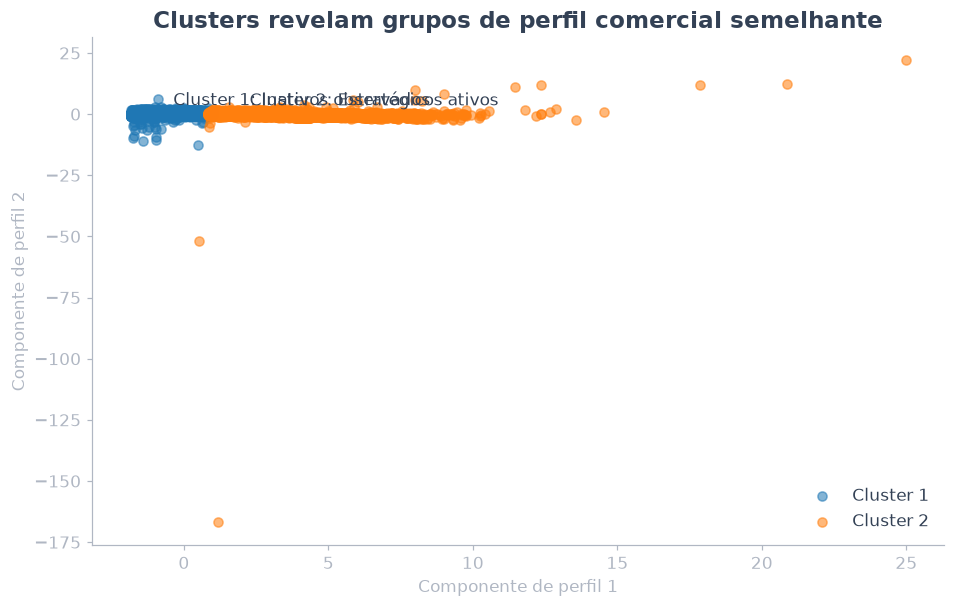

In [29]:
coordenadas = PCA(n_components=2, random_state=42).fit_transform(matriz)
mapa_cluster = pd.DataFrame(coordenadas, index=base_modelo.index, columns=['componente_1', 'componente_2'])
mapa_cluster['cluster'] = rfv.loc[base_modelo.index, 'cluster']
fig, ax = plt.subplots(figsize=(10, 6))
for grupo, pontos in mapa_cluster.groupby('cluster'):
    ax.scatter(pontos['componente_1'], pontos['componente_2'], alpha=.55, label=f'Cluster {int(grupo)}')
    centro = pontos[['componente_1', 'componente_2']].median()
    nome = perfil_cluster.loc[grupo, 'grupo_comercial']
    ax.annotate(f'Cluster {int(grupo)}: {nome}', (centro['componente_1'], centro['componente_2']), xytext=(6, 6), textcoords='offset points')
ax.set_title('Clusters revelam grupos de perfil comercial semelhante')
ax.set_xlabel('Componente de perfil 1')
ax.set_ylabel('Componente de perfil 2')
ax.legend(frameon=False)
plt.show()

**Como usar os grupos:** use o status de churn para definir urgência, RFV para escolher a ação e os clusters para adaptar a abordagem. Clientes semelhantes ajudam a comparar mix e condições. Todos os grupos descrevem padrões da base disponível; a variação de cobertura entre anos e o recorte parcial de 2026 exigem validação comercial antes de ações definitivas.

## Conclusão para gestores comerciais

- A taxa de margem melhorou nos anos completos, mesmo com recuo do faturamento. A política comercial deve proteger essa evolução.
- A margem negativa aparece em muitas linhas, mas as perdas por família são concentradas. Priorize preço, desconto, frete e mix nas famílias críticas antes de intervenções amplas.
- Produtos e revendas com maior perda absoluta devem entrar em uma lista de negociação e revisão de condições.
- O dashboard posterior deve ter filtros de período, família, produto, cliente e revenda, além de KPIs de faturamento, margem, margem percentual e perdas.